In [111]:
library(WGCNA)
# Allow multi-threading
enableWGCNAThreads()
library(DESeq2)
library(TCGAbiolinks)
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(GEOquery)
library(miRBaseConverter)
library(sva)
library(readr)
library(dplyr)
library(tidyr)
library(EnhancedVolcano)
library(biomaRt)

# EX TAIWANESE_CONSTRUCTIONS
# NOW PARAMETRIZED FOR BOTH TAIWAN AND WHITE COHORTS, SIMPLER

Allowing parallel execution with up to 11 working processes.


In [112]:
cohort <- "TAIWAN"
if (cohort == "TAIWAN") {
    config <- list(
        wd = "/home/seba/github_repos/crc_weighted_network/taiwanese_cohort/count_matrices_by_geneid",
        rna_base_counts = "RNA_merged_counts_filtered.csv",
        mirna_base_counts = "miRNA_merged_counts_filtered.csv",
        row_names_in_metadata = 1,
        metadata_file = "all_metadata_taiwan.csv",
        col_for_datatype = "Assay.Type",
        rna_datatype = "RNA-Seq",
        mirna_datatype = "miRNA-Seq",
        external_col = "PHENOTYPE",
        contrast_for_dea = c("PHENOTYPE", "neoplastic", "adjacent normal"),
        rna_network_dir = "rna_pooled_tmm",
        mirna_network_dir = "mirna_pooled_tmm",
        rna_kme_limit = 0,
        rna_kme_p_limit = 1,
        rna_gs_limit = 0.4,
        rna_gs_p_limit = 1e-02,
        mirna_kme_limit = 0,
        mirna_kme_p_limit = 1,
        mirna_gs_limit = 0.4,
        mirna_gs_p_limit = 1e-02
    )
} else if (cohort == "WHITE") {
    config <- list(
        wd = "/home/seba/github_repos/crc_weighted_network/cohort_white/count_matrices_white_byFILENAME",
        rna_base_counts = "RNA_merged_filtered.csv",
        mirna_base_counts = "mirna_new_filtered_merged.csv",
        row_names_in_metadata = 2,
        metadata_file = "gdc_sample_sheet.2026-01-21_GENES+MIRNAISOFORMS.csv",
        col_for_datatype = "Data.Type",
        rna_datatype = "Gene Expression Quantification",
        mirna_datatype = "Isoform Expression Quantification",
        external_col = "Tissue.Type",
        contrast_for_dea = c("Tissue.Type", "Tumor", "Normal"),
        rna_network_dir = "2_RNA_TMM_T_merged_counts",
        mirna_network_dir = "1_newMIRNA_TMM_T_merged_counts",
        rna_kme_limit = 0,
        rna_kme_p_limit = 1,
        rna_gs_limit = 0.4,
        rna_gs_p_limit = 1e-02,
        mirna_kme_limit = 0,
        mirna_kme_p_limit = 1,
        mirna_gs_limit = 0.4,
        mirna_gs_p_limit = 1e-02
    )
}

In [113]:
# set working directory
setwd(config$wd)

In [114]:
# Load RNA and miRNA data, ENSURE THESE COME PRE-FILTERED (remove low counts)
rna_counts <- read.csv(config$rna_base_counts, row.names = 1, sep=",", header=TRUE, check.names = FALSE)
mirna_counts <- read.csv(config$mirna_base_counts, row.names = 1, sep=",", header=TRUE, check.names = FALSE)


# Load metadata
metadata <- read.csv(config$metadata_file, row.names = config$row_names_in_metadata, header=TRUE)
rna_metadata <- metadata[metadata[[config$col_for_datatype]] == config$rna_datatype, ]
mirna_metadata <- metadata[metadata[[config$col_for_datatype]] == config$mirna_datatype, ]

# ensure order
rna_metadata <- rna_metadata[colnames(rna_counts), ]
mirna_metadata <- mirna_metadata[colnames(mirna_counts), ]

# write also the same rna and mirna raw counts but transposed
write.csv(as.data.frame(rna_counts), file="RNA_merged_T_filtered.csv")
write.csv(as.data.frame(mirna_counts), file="miRNA_merged_T_filtered.csv")

In [115]:
# Do the differential expression analysis
dds <- DESeqDataSetFromMatrix(countData = rna_counts,
                    colData = rna_metadata,
                    design = as.formula(paste0("~", config$external_col)))

dds <- DESeq(dds)
res <- results(dds, contrast=config$contrast_for_dea)
res_ordered <- res[order(res$padj), ]

df_rna = res_ordered
df_rna$Category <- "Not significant" # Criteria can be changed
df_rna[which(df_rna$log2FoldChange > 1 & df_rna$padj <= 0.001),]$Category <- "Up-regulated"
df_rna[which(df_rna$log2FoldChange <= -1 & df_rna$padj <= 0.001),]$Category <- "Down-regulated"

#df_rna <- df_rna[df_rna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

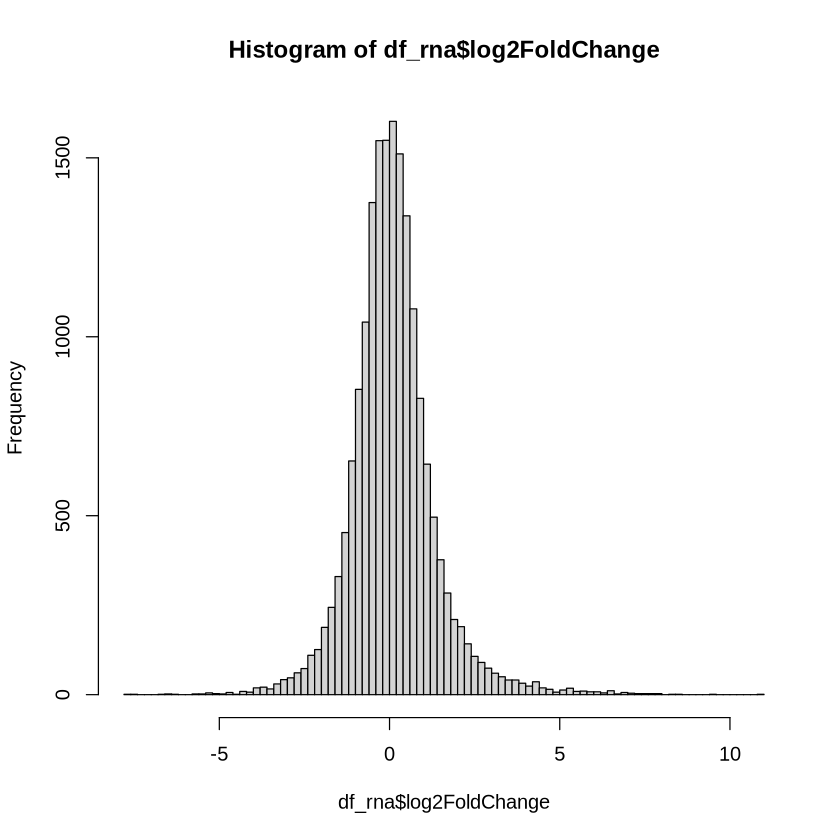

In [116]:
hist(df_rna$log2FoldChange, breaks = 100)

Warning message:
“One or more p-values is 0. Converting to 10^-1 * current lowest non-zero p-value...”


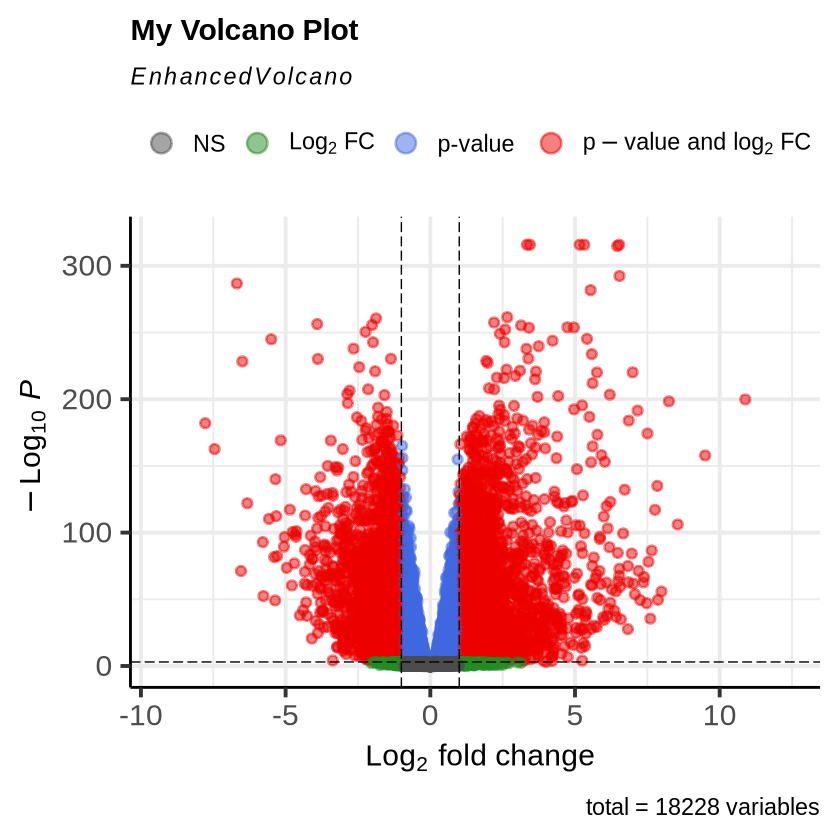

In [117]:
EnhancedVolcano(df_rna,
                lab = rownames(df_rna), # Your gene names
                x = 'log2FoldChange',   # Your log2 fold-change column
                y = 'padj',           # Your p-value column
                title = 'My Volcano Plot',
                pCutoff = 0.001,
                FCcutoff = 1,
                labSize = 0)

In [118]:
# DESeq2 on mirna data now
mirna_merged_raw <- as.matrix(mirna_counts)
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_merged_raw,
                colData = mirna_metadata,
                design = as.formula(paste0("~", config$external_col)))

dds_mirna <- DESeq(dds_mirna)
res_mirna <- results(dds_mirna, contrast=config$contrast_for_dea)
res_mirna = res_mirna[order(res_mirna$padj), ]
res_mirna <- res_mirna[!is.na(res_mirna$padj), ]

res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # Criteria can be changed
df_mirna[which(df_mirna$log2FoldChange > 1 & df_mirna$padj <= 0.001),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange <= -1 & df_mirna$padj <= 0.001),]$Category <- "Down-regulated"

if (cohort == "TAIWAN") {
    new_mirnanames <- miRNA_NameToAccession(rownames(df_mirna),version = "v22")
    rownames(df_mirna) <- new_mirnanames$Accession   
}

#df_mirna <- df_mirna[df_mirna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
 

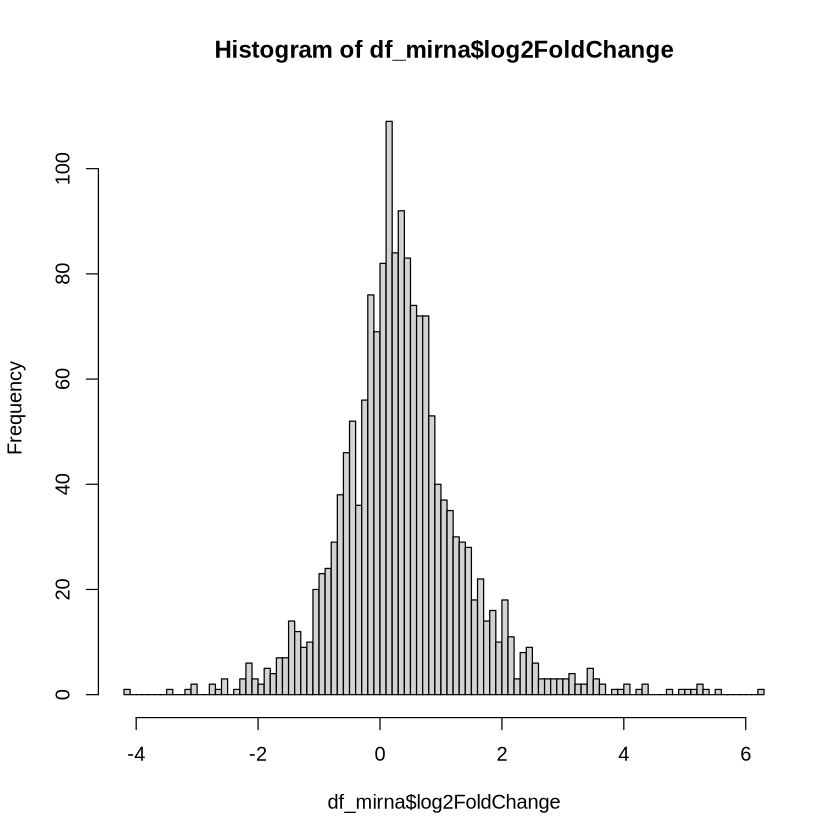

In [119]:
hist(df_mirna$log2FoldChange, breaks = 100)

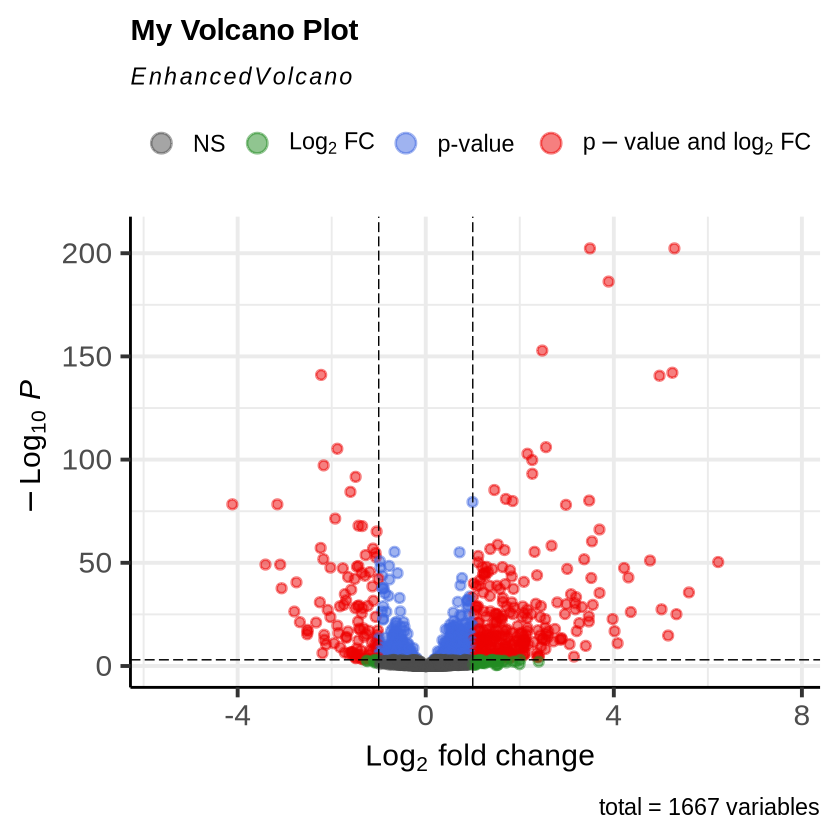

In [120]:
EnhancedVolcano(df_mirna,
                lab = rownames(df_mirna), # Your gene names
                x = 'log2FoldChange',   # Your log2 fold-change column
                y = 'padj',           # Your p-value column
                title = 'My Volcano Plot',
                pCutoff = 0.001,
                FCcutoff = 1,
                labSize = 0)

In [121]:
# write rna and mirna results to tsv files
write.table(df_rna, file="DESeq2_RNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)
write.table(df_mirna, file="DESeq2_miRNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)

In [122]:
# save DESeq2 normalized counts too
norm_counts <- counts(dds, normalized=TRUE)
vsd_counts <- varianceStabilizingTransformation(dds, blind = TRUE)

norm_counts_mirna <- counts(dds_mirna, normalized=TRUE)
vsd_counts_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)

#rlog_counts <- rlog(dds, blind=TRUE)
#rlog_counts_mirna <- rlog(dds_mirna, blind=TRUE)

write.csv(t(as.data.frame(norm_counts)), file="RNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts)), file="RNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts)), file="rna_rlog_counts.csv")

write.csv(t(as.data.frame(norm_counts_mirna)), file="miRNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts_mirna)), file="miRNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts_mirna)), file="mirna_rlog_counts.csv")

In [123]:
vsd <- varianceStabilizingTransformation(dds, blind = TRUE)
pca <- prcomp(t(assay(vsd)), scale. = FALSE)
percentVar <- (pca$sdev^2) / sum(pca$sdev^2)

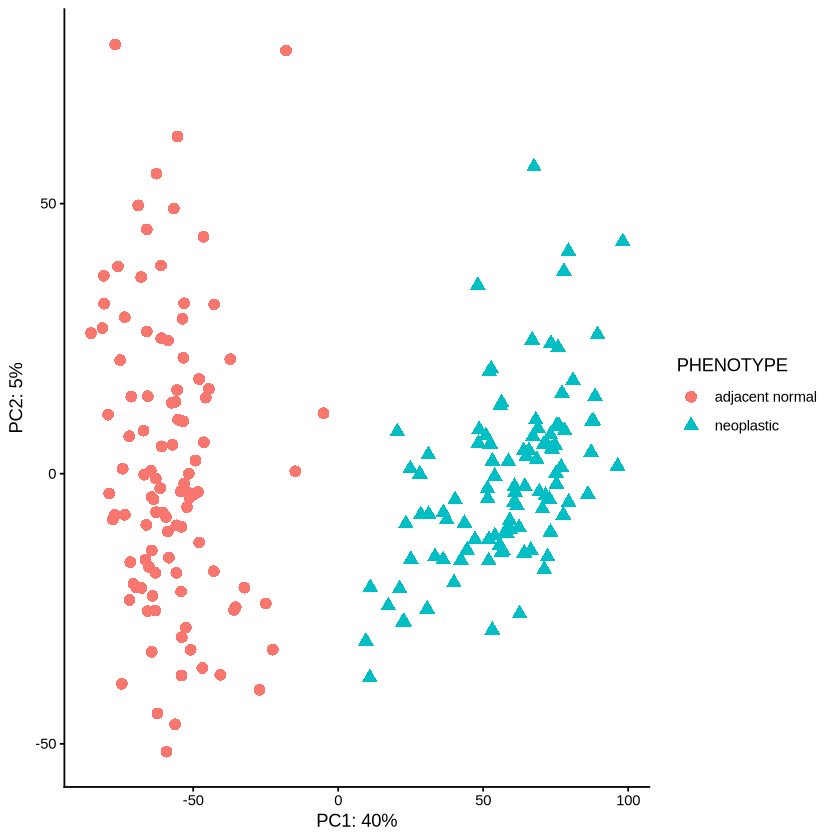

In [124]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  rna_metadata
)

ggplot(pca_df, aes(PC1, PC2,
                   color = .data[[config$external_col]],
                   shape = .data[[config$external_col]])) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [125]:
vsd_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)
pca_mirna <- prcomp(t(assay(vsd_mirna)), scale. = FALSE)
percentVar <- (pca_mirna$sdev^2) / sum(pca_mirna$sdev^2)

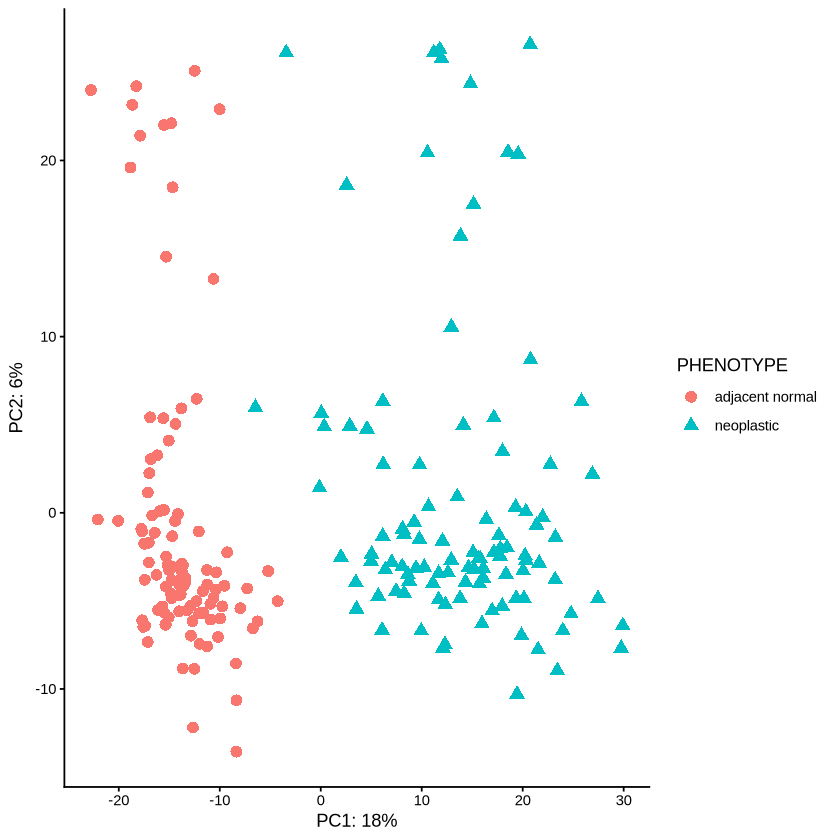

In [126]:
pca_df_mirna <- data.frame(
  PC1 = pca_mirna$x[,1],
  PC2 = pca_mirna$x[,2],
  mirna_metadata
)

ggplot(pca_df_mirna, aes(PC1, PC2,
                   color = .data[[config$external_col]],
                   shape = .data[[config$external_col]])) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [127]:
rna_network_dir <- paste0("../", config$rna_network_dir)

In [128]:
rna_network_dir

[1] "../rna_pooled_tmm"

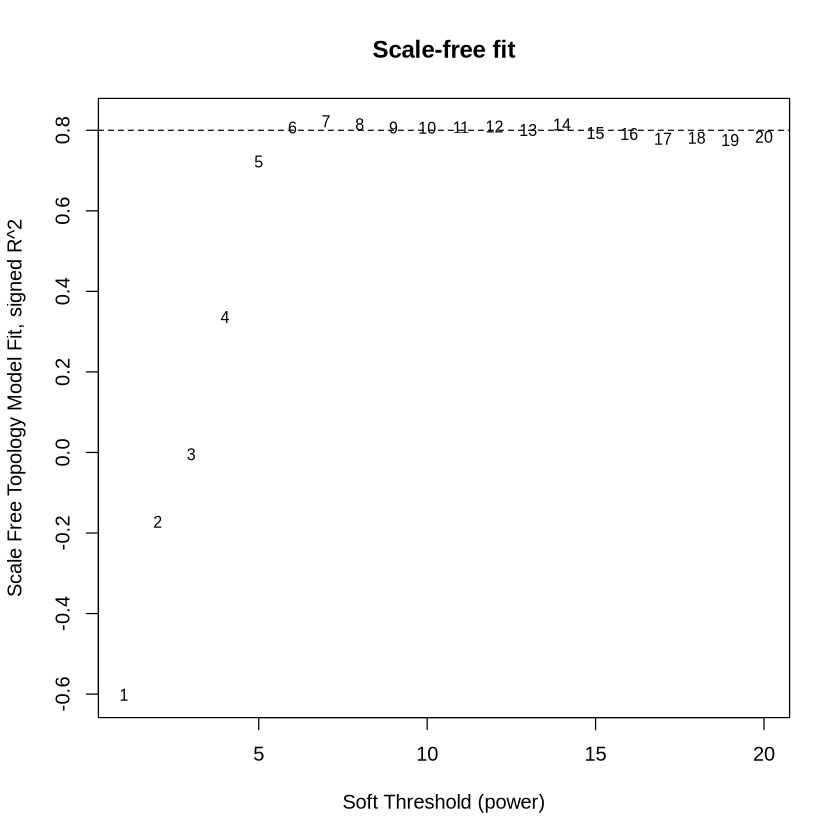

In [129]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS(paste(rna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

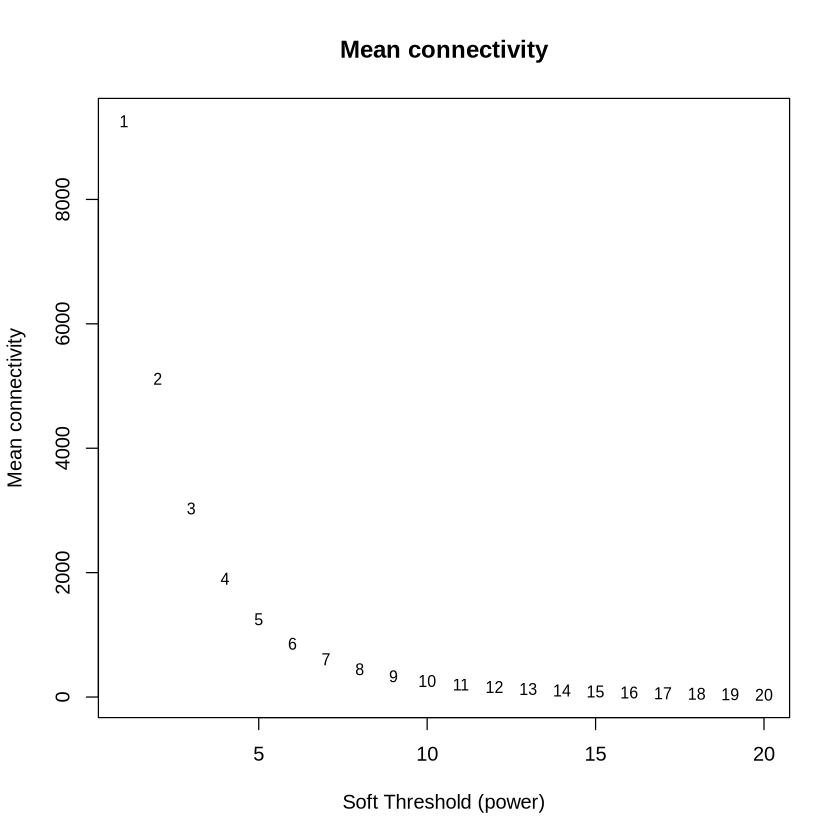

In [130]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

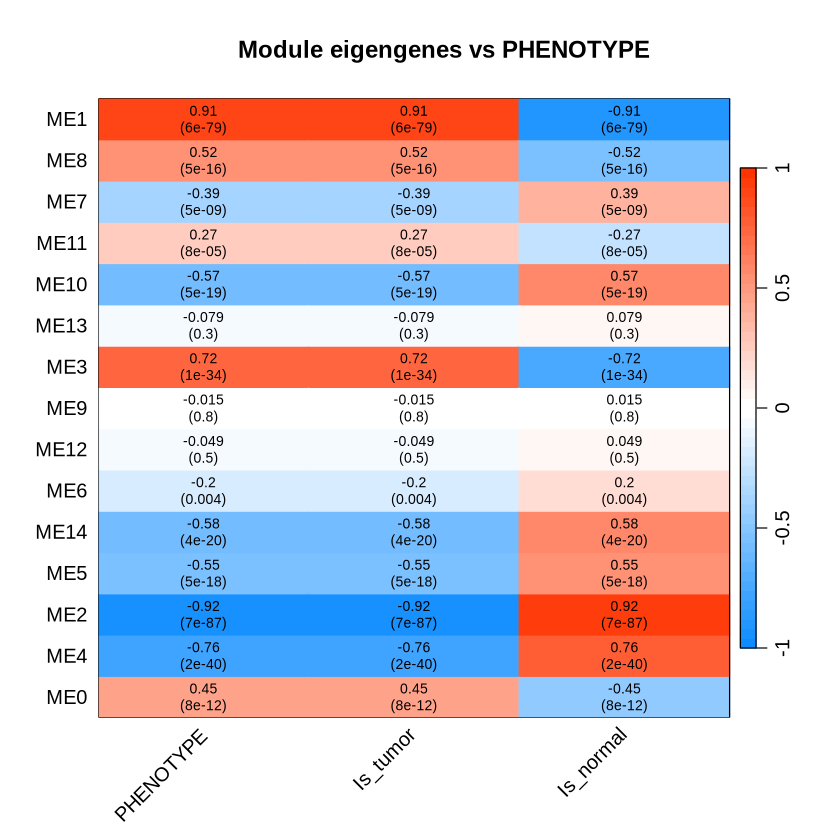

In [131]:
# Load
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!(config$external_col %in% colnames(traits))) stop("External column not found in traits.")

trait_pheno <- traits[, config$external_col, drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno[[config$external_col]])) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno[[config$external_col]]))
  if (length(lev) != 2) {
    stop(paste0(
      "External column must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev) # tumor must be 1 and normal must be 0
  trait_pheno[[config$external_col]] <- ifelse(as.character(trait_pheno[[config$external_col]]) == lev[2], 1, 0) # THIS IF FOR TUMOR=1, NORMAL=0
}

# add new columns: Is_tumor and Is_normal
trait_pheno$Is_tumor <- ifelse(trait_pheno[[config$external_col]] == 1, 1, 0)
trait_pheno$Is_normal <- ifelse(trait_pheno[[config$external_col]] == 1, 0, 1)

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = c(config$external_col, "Is_tumor", "Is_normal"),
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = paste0("Module eigengenes vs ", config$external_col)
)

In [132]:
# print heatmap as only values
rna_ME_traitcor <- MEtraitCor
write.csv(MEtraitCor, file = paste(rna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [133]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net

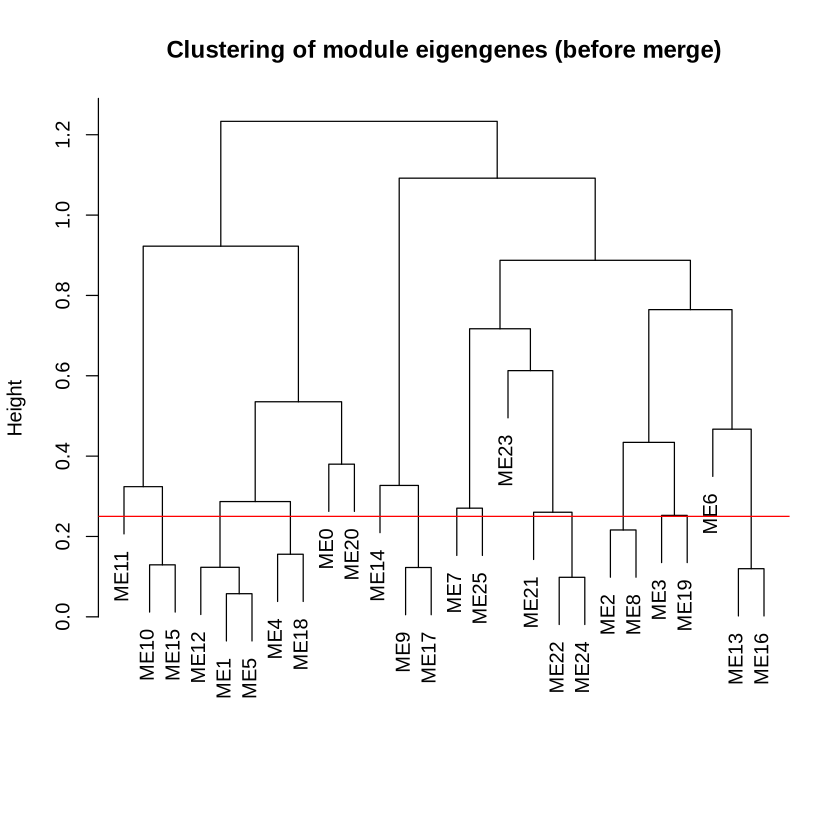

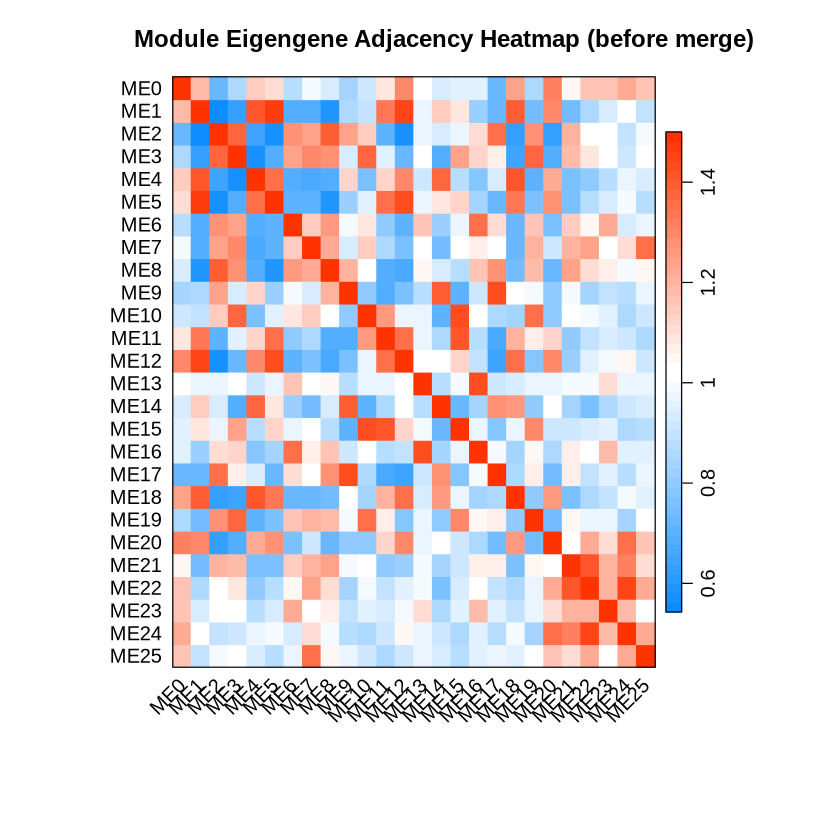

In [134]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.25, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

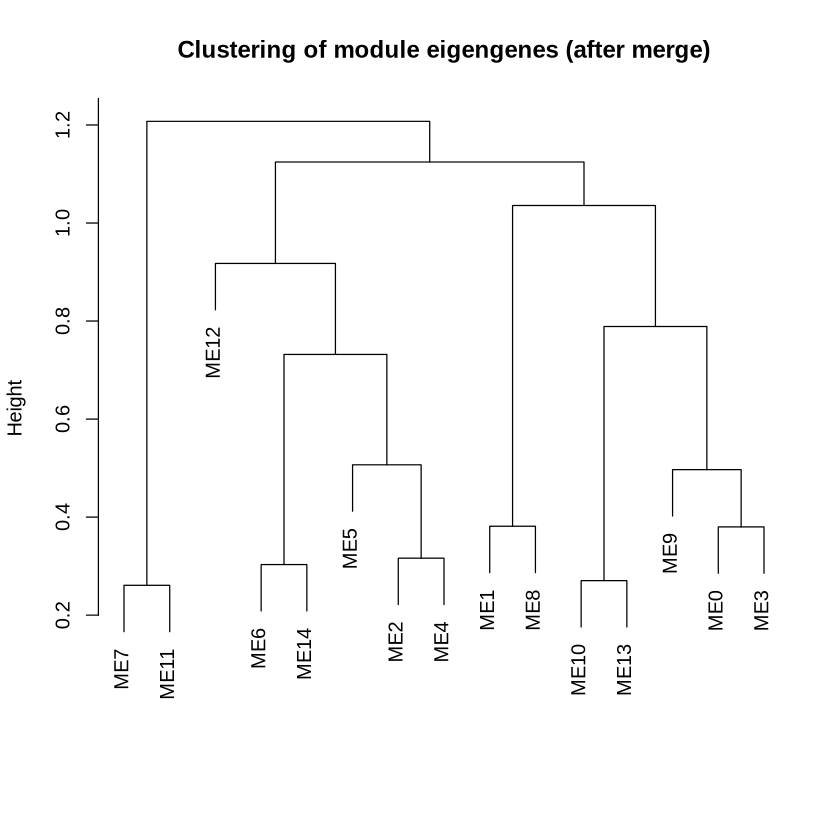

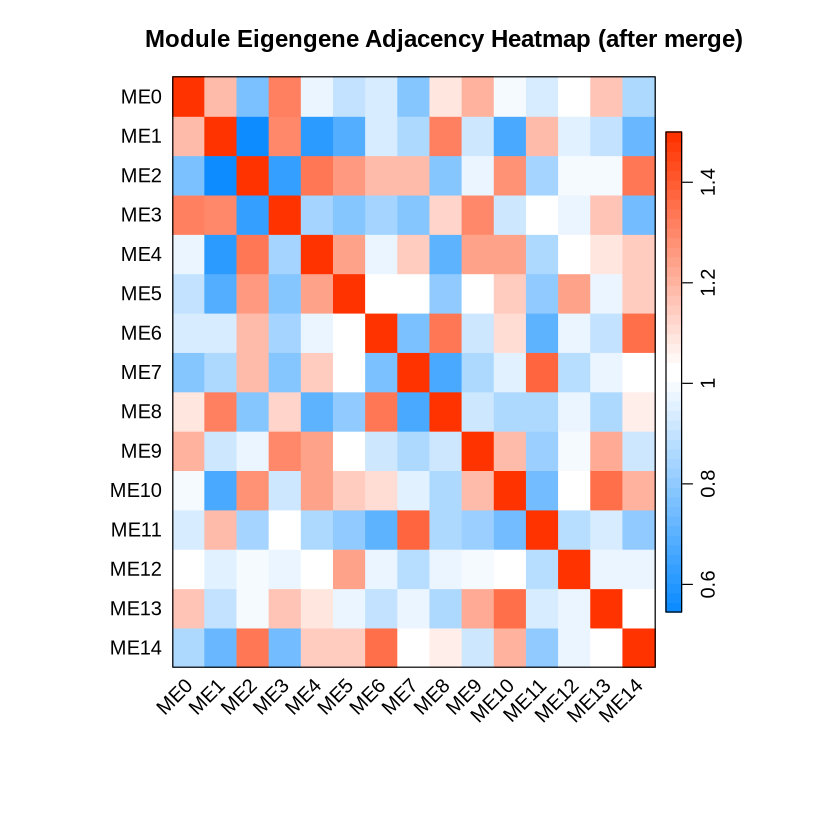

In [135]:
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [136]:
mirna_network_dir <- paste0("../", config$mirna_network_dir)

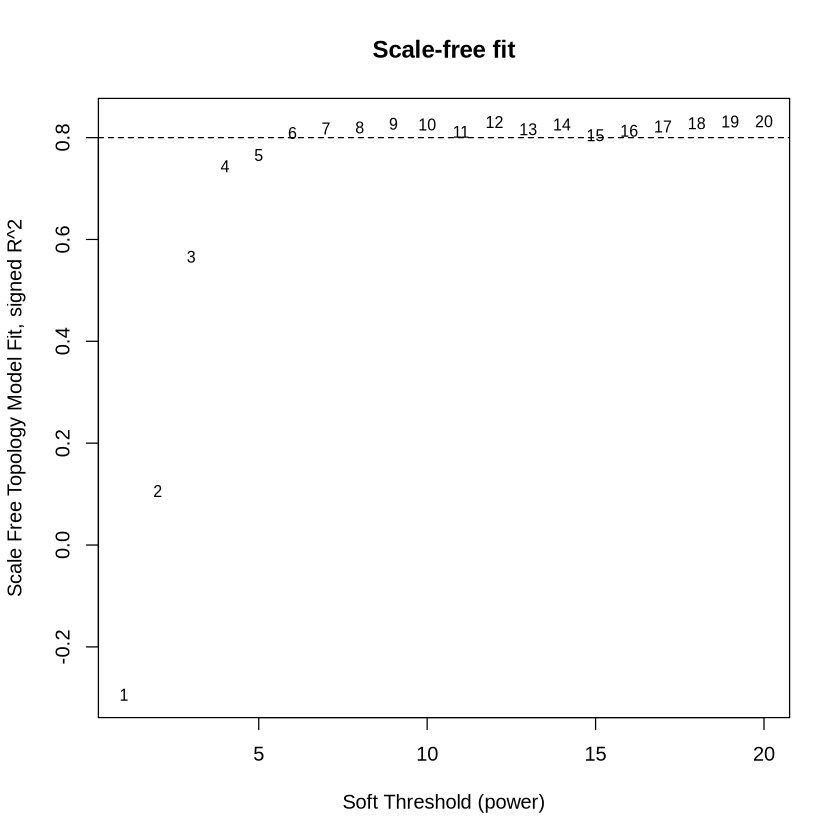

In [137]:
# Load the pre-computed WGCNA modules of miRNA pooled
sft <- readRDS(paste(mirna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line

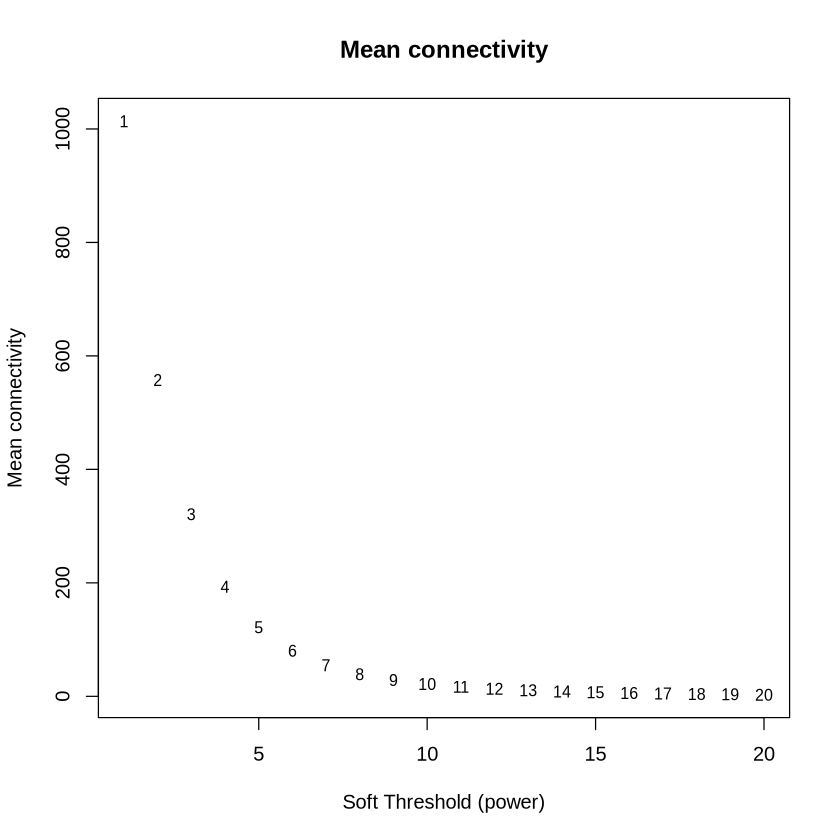

In [138]:
meanK <- sft$fitIndices[,5]  # mean connectivity

plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)

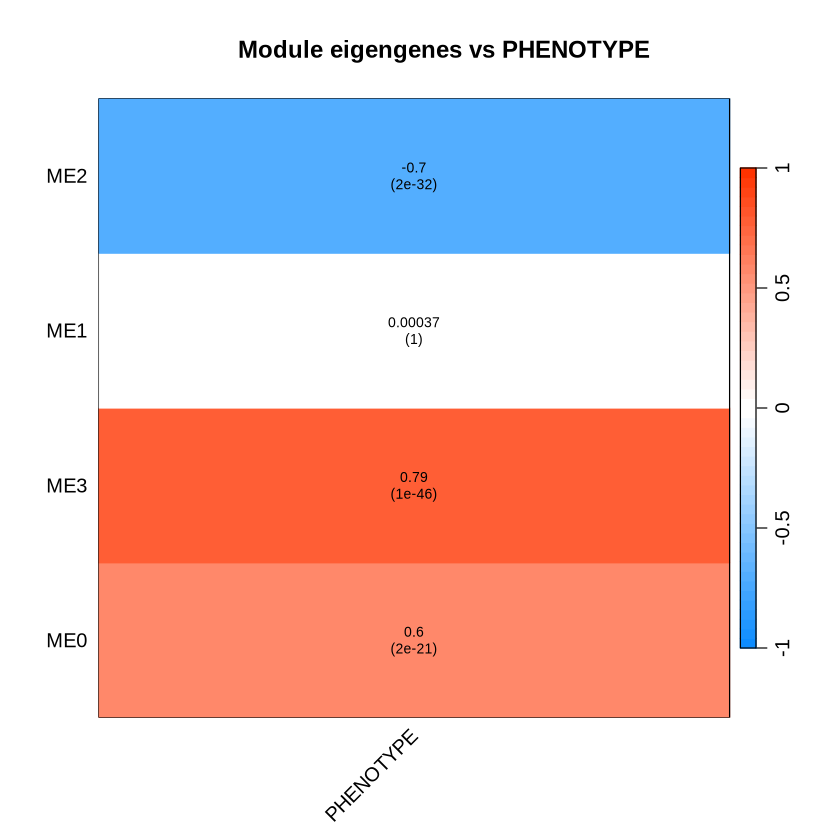

In [139]:
# Load
MEs    <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(mirna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!(config$external_col %in% colnames(traits))) stop("External column not found in traits.")

trait_pheno <- traits[, config$external_col, drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno[[config$external_col]])) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno[[config$external_col]]))
  if (length(lev) != 2) {
    stop(paste0(
      "External col must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno[[config$external_col]] <- ifelse(as.character(trait_pheno[[config$external_col]]) == lev[2], 1, 0)
}

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = config$external_col,
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = paste0("Module eigengenes vs ", config$external_col)
)

In [140]:
miRNA_traitCor <- MEtraitCor
write.csv(MEtraitCor, file = paste(mirna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [141]:
net <- readRDS(paste(mirna_network_dir, "/blockwise_net.rds", sep=""))
mirna_net <- net

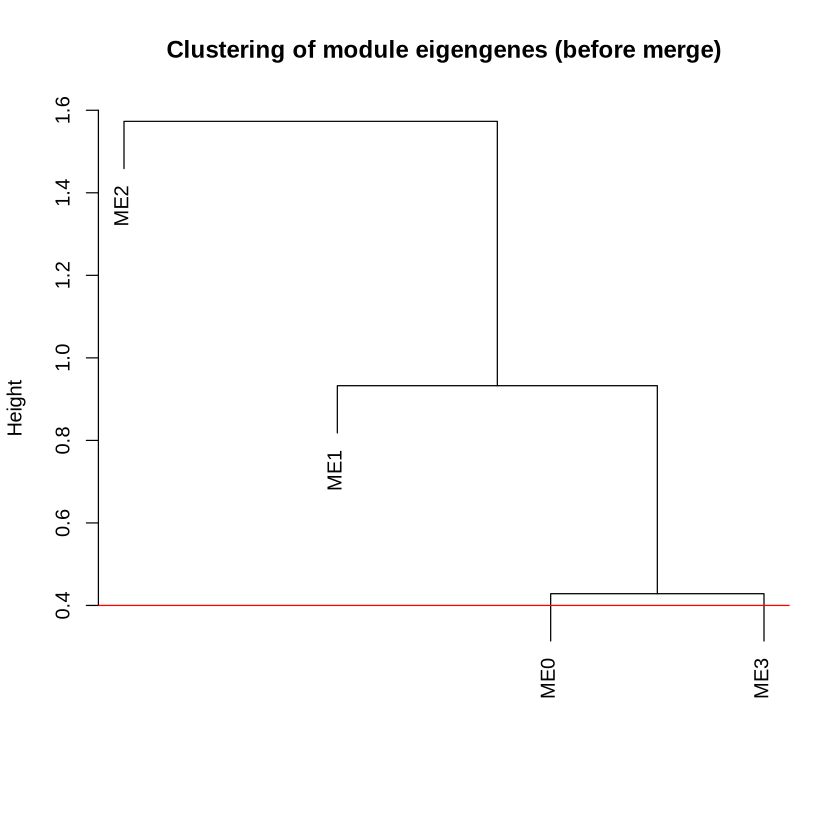

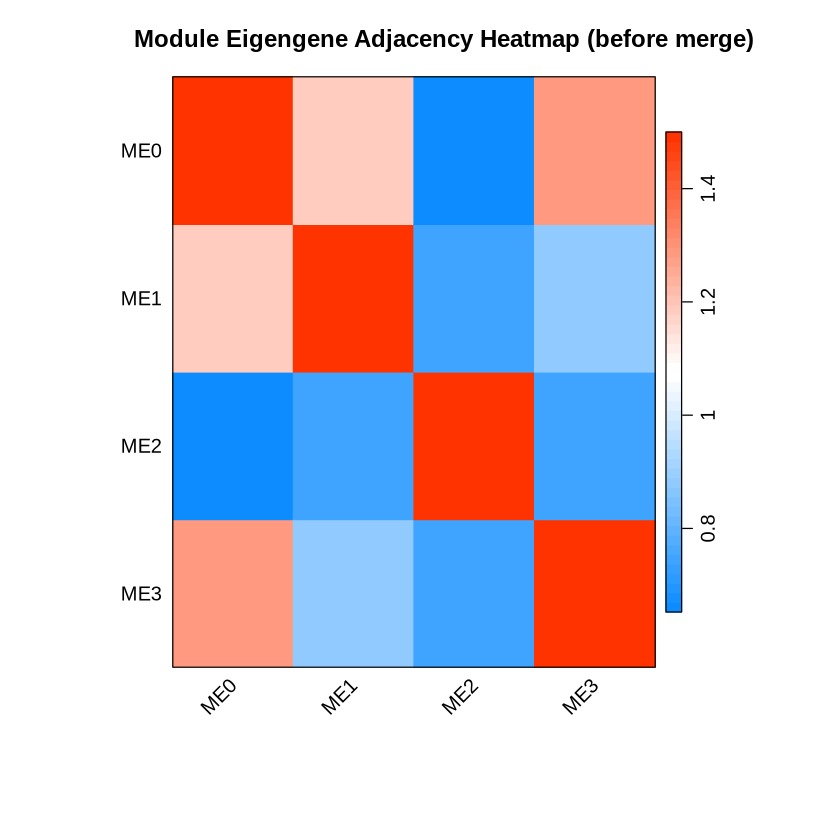

In [142]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.4, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

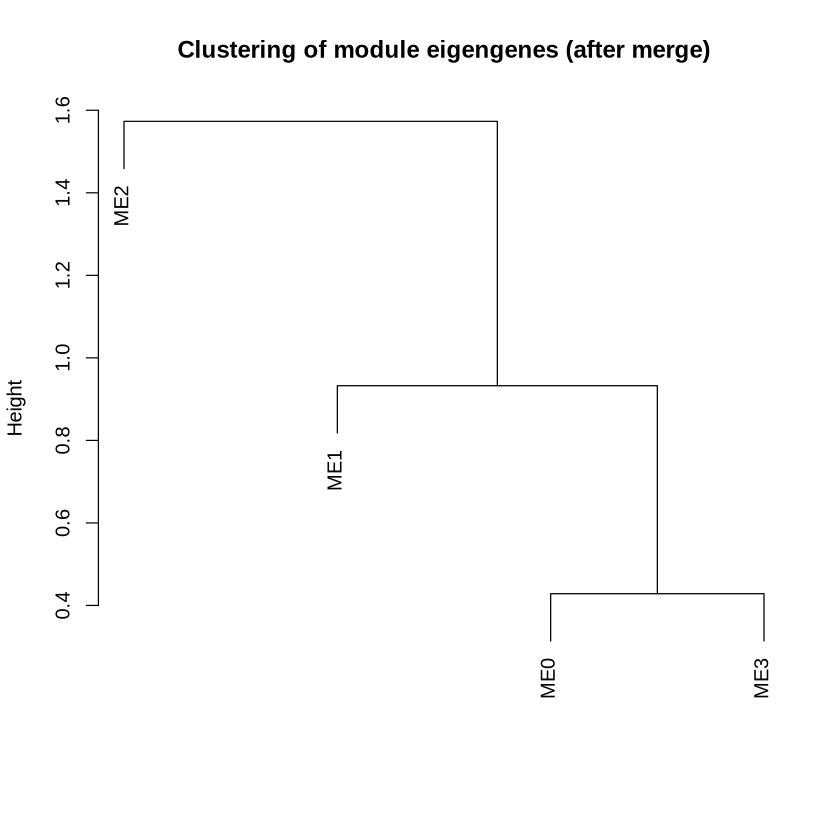

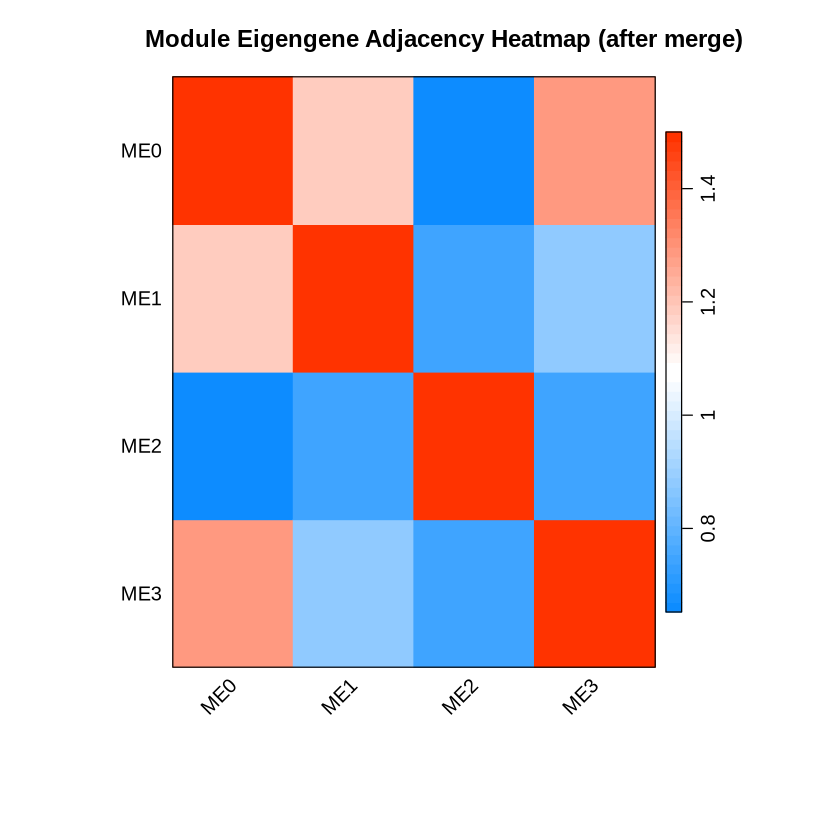

In [143]:
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [144]:
filter_genes <- function(df, kme_limit, kme_p_limit, gs_limit, gs_p_limit) {
  
  # 1. Identificar automáticamente las columnas kME (los valores de correlación)
  # Buscamos columnas que empiecen con kME_ME y terminen en un número (no en _P)
  cols_kme <- grep("^kME_ME\\d+$", colnames(df), value = TRUE)
  
  message("Módulos detectados para el filtro: ", paste(cols_kme, collapse = ", "))

  # 3. Aplicar el filtro dinámico
  df_filtrado <- df %>%
    # Filtro de Fenotipo (GS)
    filter(abs(.data[[paste0("GS_", config$external_col)]]) > gs_limit & .data[[paste0("GS_", config$external_col, "_P")]] < gs_p_limit) %>%
    
    # Filtro de Membresía (kME) horizontal
    rowwise() %>%
    filter({
      # Verificamos si existe algún par (kME, kME_P) que cumpla la condición
      any(sapply(cols_kme, function(col) {
        p_col <- paste0(col, "_P")
        
        # Validación de seguridad: verificar que la columna _P exista en el df
        if (!p_col %in% colnames(df)) return(FALSE)
        
        val_kme <- get(col)
        val_p   <- get(p_col)
        
        # El gen debe cumplir ambos criterios en el MISMO módulo
        !is.na(val_kme) && abs(val_kme) > kme_limit && 
        !is.na(val_p)   && val_p < kme_p_limit
      }))
    }) %>%
    ungroup()

  return(as.data.frame(df_filtrado))
}

In [145]:
MEs_rna <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
MEs_mirna <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))

In [146]:
# get list modules with |r| > thresh with PHENOTYPE from miRNA_traitCor and rna_ME_traitcor #miRNA_traitCor #rna_ME_traitcor

cor_thresh <- 0
MEs_rna <- rna_ME_traitcor[which(abs(rna_ME_traitcor[,1]) > cor_thresh), , drop=FALSE]
MEs_mirna <- miRNA_traitCor[which(abs(miRNA_traitCor[,1]) > cor_thresh), , drop=FALSE]

# remove ME0 from MEs_rna and MEs_mirna
MEs_rna <- MEs_rna[!rownames(MEs_rna) %in% "ME0", , drop=FALSE]
MEs_mirna <- MEs_mirna[!rownames(MEs_mirna) %in% "ME0", , drop=FALSE]

# REMOVE ME from the name
rownames(MEs_rna) <- gsub("ME", "", rownames(MEs_rna))
rownames(MEs_mirna) <- gsub("ME", "", rownames(MEs_mirna))

MEs_rna <- as.data.frame(MEs_rna)
MEs_rna$moduleNumber <- rownames(MEs_rna)

MEs_mirna <- as.data.frame(MEs_mirna)
MEs_mirna$moduleNumber <- rownames(MEs_mirna)

# hasta aca se tienen los listados de modules significativos para rna y miRNA en moduleNumber

# reemplazar cada moduleNumber por kME_ME_number para poder hacer el merge
MEs_rna$kme_ME_number <- paste("kME_ME", MEs_rna$moduleNumber, sep="")
MEs_mirna$kme_ME_number <- paste("kME_ME", MEs_mirna$moduleNumber, sep="")


# List of which to keep (will be all of them if cor_thresh = 0)
kMEs_keep_rna <- MEs_rna$kme_ME_number
KMEs_P_keep_rna <- paste(kMEs_keep_rna, "_P", sep="")
GS_keep_rna <- c(paste0("GS_", config$external_col), paste0("GS_", config$external_col, "_P"))

kMEs_keep_mirna <- MEs_mirna$kme_ME_number
KMEs_P_keep_mirna <- paste(kMEs_keep_mirna, "_P", sep="")
GS_keep_mirna <- c(paste0("GS_", config$external_col), paste0("GS_", config$external_col, "_P"))

In [147]:
# kME tables
kme_table_rna <- readRDS(paste(rna_network_dir, "/kME_table.rds", sep=""))
kme_table_rna_P <- readRDS(paste(rna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables
GS_table_rna <- readRDS(paste(rna_network_dir, "/GS_table.rds", sep=""))
GS_table_rna_P <- readRDS(paste(rna_network_dir, "/GS_P_table.rds", sep=""))

# fuse rna tables
rna_table <- cbind(kme_table_rna, kme_table_rna_P, GS_table_rna, GS_table_rna_P)
# drop gene column
rna_table <- rna_table[, c(kMEs_keep_rna, KMEs_P_keep_rna, GS_keep_rna)]
rna_table$gene <- rownames(rna_table)

In [148]:
selected_rna <- filter_genes(rna_table, kme_limit = config$rna_kme_limit, kme_p_limit = config$rna_kme_p_limit, 
                            gs_limit = config$rna_gs_limit, gs_p_limit = config$rna_gs_p_limit)

Módulos detectados para el filtro: kME_ME1, kME_ME8, kME_ME7, kME_ME11, kME_ME10, kME_ME13, kME_ME3, kME_ME9, kME_ME12, kME_ME6, kME_ME14, kME_ME5, kME_ME2, kME_ME4



In [149]:
# kME tables for miRNA
kme_table_mirna <- readRDS(paste(mirna_network_dir, "/kME_table.rds", sep=""))
kme_table_mirna_P <- readRDS(paste(mirna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables for miRNA
GS_table_mirna <- readRDS(paste(mirna_network_dir, "/GS_table.rds", sep=""))
GS_table_mirna_P <- readRDS(paste(mirna_network_dir, "/GS_P_table.rds", sep=""))

# fuse mirna tables
mirna_table <- cbind(kme_table_mirna, kme_table_mirna_P, GS_table_mirna, GS_table_mirna_P)
mirna_table <- mirna_table[, c(kMEs_keep_mirna, KMEs_P_keep_mirna, GS_keep_mirna)]
mirna_table$gene <- rownames(mirna_table)

In [150]:
selected_mirna <- filter_genes(mirna_table, kme_limit = config$mirna_kme_limit, kme_p_limit = config$mirna_kme_p_limit,
                                gs_limit = config$mirna_gs_limit, gs_p_limit = config$mirna_gs_p_limit)

Módulos detectados para el filtro: kME_ME2, kME_ME1, kME_ME3



In [151]:
# METRODO DE FILTRADO ALTERNATIVO: TOP 1000 GENES Y TOP 500 MIRNAS
n_top_genes <- 1000
n_top_mirnas <- 500

# 1. Seleccionar Top Genes
top_genes <- rna_table %>%
  filter(.data[[paste0("GS_", config$external_col, "_P")]] < 0.05) %>% # Primero aseguramos que sean significativos
  arrange(desc(abs(.data[[paste0("GS_", config$external_col)]]))) %>%
  slice_head(n = n_top_genes) %>%
  pull(gene)

# 2. Seleccionar Top miRNAs
top_mirnas <- mirna_table %>%
  filter(.data[[paste0("GS_", config$external_col, "_P")]] < 0.05) %>%
  arrange(desc(abs(.data[[paste0("GS_", config$external_col)]]))) %>%
  slice_head(n = n_top_mirnas) %>%
  pull(gene)

In [152]:
length(top_genes)
length(top_mirnas)

[1] 1000

[1] 500

In [153]:
# load ENCORI dataframe
encori_filtered <- read_tsv("../../ENCORI_hg38_miRNA-mRNA_FILTERED.tsv")

Rows: 219690 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (9): miRNAid, miRNAname, geneID, geneName, geneType, chromosome, strand...
dbl (18): narrowStart, narrowEnd, broadStart, broadEnd, clipExpNum, degraExp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [154]:
# remove the .XX in the selected_rna genes
# genes_selected_rna_noversion <- gsub("\\.\\d+$", "", selected_rna$gene)
genes_selected_rna_noversion <- gsub("\\.\\d+$", "", top_genes) # COMENTAR O BORRAR SI NO SE QUIERE TOP

In [155]:
length(unique(encori_filtered$geneID))
length(unique(encori_filtered$miRNAname))

[1] 11237

[1] 205

In [156]:
if (cohort == "TAIWAN") {
    mirnas <- miRNAVersionConvert(selected_mirna$gene, targetVersion = "v22", exact=TRUE)$Accession
    mirnas <- miRNAVersionConvert(top_mirnas, targetVersion = "v22", exact=TRUE)$Accession # COMENTAR SI NO SE QUIERE TRABAJAR CON EL TOP
} else if (cohort == "WHITE") {
    #mirnas <- selected_mirna$gene    
    mirnas <- top_mirnas # COMENTAR SI NO SE QUIERE TRABAJAR CON EL TOP
}

In [157]:
edges_selected <- encori_filtered %>%
  filter(
    geneID %in% genes_selected_rna_noversion &
    miRNAid %in% mirnas
  )

In [158]:
dim(edges_selected)

[1] 8015   27

In [159]:
unique_encori <- edges_selected %>%
  group_by(miRNAid, geneID) %>%
  summarise(
    weight = n(), # Cuenta cuántas veces aparece el par
    .groups = 'drop'
  )

In [160]:
dim(unique_encori)
length(unique(unique_encori$miRNAid))
length(unique(unique_encori$geneID))

[1] 5989    3

[1] 90

[1] 713

In [161]:
rownames(df_rna) <- gsub("\\.\\d+$", "", rownames(df_rna))
df_rna <- as.data.frame(df_rna)
df_mirna <- as.data.frame(df_mirna)

In [162]:
# 1. Obtener TODOS los nodos que existen en la red de ENCORI
# Combinamos la columna de miRNAs y la de Genes para tener el universo completo de nodos
nodos_en_red <- data.frame(
  NodeID = unique(c(unique_encori$miRNAid, unique_encori$geneID))
)

# 2. Preparar las tablas de referencia (como diccionarios)
ref_genes <- data.frame(
  NodeID = rownames(df_rna),
  Category = df_rna$Category,
  NodeType_Ref = "Gene"
)

ref_mirnas <- data.frame(
  NodeID = rownames(df_mirna),
  Category = df_mirna$Category,
  NodeType_Ref = "miRNA"
)

# Unimos ambas referencias en una sola tabla de búsqueda
referencia_total <- bind_rows(ref_genes, ref_mirnas)

# 3. Unir el universo de la red con la información disponible
master_node_table <- nodos_en_red %>%
  left_join(referencia_total, by = "NodeID")

# 4. Manejar los NAs
# Si no se encontró en las tablas de expresión, asignamos "NA" o "Not_Found"
master_node_table <- master_node_table %>%
  mutate(
    Category = replace_na(as.character(Category), "NA"),
    # Intentamos adivinar el tipo si no estaba en la tabla (por el nombre del ID)
    NodeType = case_when(
      !is.na(NodeType_Ref) ~ NodeType_Ref,
      grepl("hsa-", NodeID) | grepl("MIMAT", NodeID) ~ "miRNA",
      TRUE ~ "Gene"
    )
  ) %>%
  select(NodeID, Category, NodeType)

In [163]:
#master_node_table # despues anotar: para todos los miRNA usar miRBaseConverter y para todos los genes usar lo de BioMart
# --- PASO 1: Identificar y Separar ---
genes_ids <- master_node_table %>% filter(NodeType == "Gene") %>% pull(NodeID)
mirnas_ids <- master_node_table %>% filter(NodeType == "miRNA") %>% pull(NodeID)

# --- PASO 2: Convertir Genes con BioMart ---
# Conectamos con el servidor de Ensembl
mart <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")

genes_map <- getBM(
  attributes = c("ensembl_gene_id", "external_gene_name"),
  filters = "ensembl_gene_id",
  values = genes_ids,
  mart = mart
)

# --- PASO 3: Convertir miRNAs con miRBaseConverter ---
# Convertimos de MIMAT (Accession) a Name (Mature ID)
mirnas_map <- miRNA_AccessionToName(
  mirnas_ids, 
  targetVersion = "v22"
)

# --- PASO 4: Actualizar la Master Node Table ---
master_node_table_final <- master_node_table %>%
  # Unir nombres de genes
  left_join(genes_map, by = c("NodeID" = "ensembl_gene_id")) %>%
  # Unir nombres de miRNAs
  left_join(mirnas_map, by = c("NodeID" = "Accession")) %>%
  # Crear columna unificada de 'Name'
  mutate(
    NodeName = case_when(
      NodeType == "Gene" ~ external_gene_name,
      NodeType == "miRNA" ~ TargetName,
      TRUE ~ NodeID # Si es NA o no se encontró, dejamos el ID original
    )
  ) %>%
  # Limpiar columnas temporales y dejar el ID y el Name
  select(NodeID, NodeName, Category, NodeType)

In [164]:
# 5. Guardar para Cytoscape
write.csv(master_node_table_final, "node_annotation_cytoscape.csv", row.names = FALSE)

In [165]:
dim(unique_encori)
write.table(unique_encori, file=paste0("ENCORI_filtered_edges_selected_modules_", cohort, ".tsv"), sep="\t", quote=FALSE, row.names=FALSE, col.names = TRUE)

[1] 5989    3